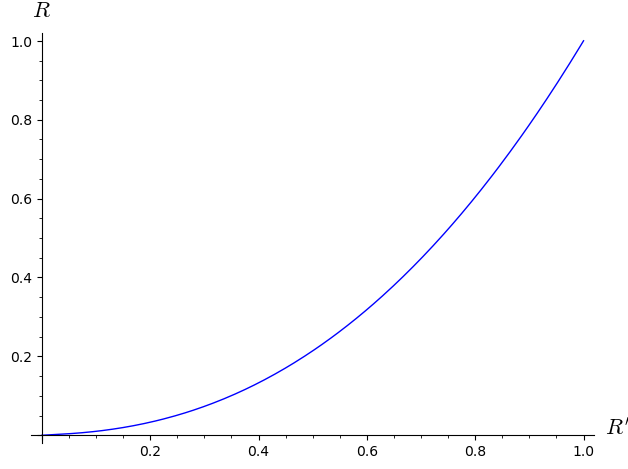

In [12]:
def gamma(r):
    if r <= 0.04045:
        return r / 12.92
    else:
        return ((r + 0.055) / 1.055) ** 2.4

plot(gamma, xmin=0, xmax=1, axes_labels=["$R'$", "$R$"])

In [80]:
from sage.plot.plot3d.index_face_set import IndexFaceSet
from sage.plot.plot3d.texture import Texture

def oklab2rgb(L, a, b):
    M1 = matrix([
        [1.0, 0.3963377774, 0.2158037573],
        [1.0, -0.1055613458, -0.0638541728],
        [1.0, -0.0894841775, -1.2914855480],
    ])

    M2 = matrix([
        [4.0767416621, -3.3077115913, 0.2309699292],
        [-1.2684380046, 2.6097574011, -0.3413193965],
        [-0.0041960863, -0.7034186147, 1.7076147010],
    ])

    v = vector([L, a, b])
    v = M1 * v
    v = v.apply_map(lambda x: x ** 3)
    v = M2 * v
    return v

def srgb_oetf(x):
    if x > 0.0031308:
        return (1.055 * (x ** (1/2.4)) - 0.055)
    else:
        return 12.92 * x

def plot_fn(x, y, z):
    r, g, b = oklab2rgb(z, x, y)
    qr = abs(r - 0.5) - 0.5
    qg = abs(g - 0.5) - 0.5
    qb = abs(b - 0.5) - 0.5

    # Distance for points outside the cube
    external_dist = sqrt(
        max(qr, 0) ** 2 + max(qg, 0) ** 2 + max(qb, 0) ** 2
    )
    # Distance for points inside the cube (will be 0 or negative)
    internal_dist = min(max(qr, qg, qb), 0)
    return external_dist + internal_dist

var('L', 'a', 'b')

p = implicit_plot3d(plot_fn, (a, -0.5, 0.5), (b, -0.5, 0.5), (L, 0, 1), plot_points=80)
p.triangulate()
faces = p.face_list()
def get_face_color(face):
    l = sum(vert[2] for vert in face) / len(face)
    a = sum(vert[0] for vert in face) / len(face)
    b = sum(vert[1] for vert in face) / len(face)
    return tuple(max(0, min(channel, 1)) for channel in tuple(oklab2rgb(l, a, b)))
    
colors = [Texture(get_face_color(face)) for face in faces]

class MyIndexFaceSet(IndexFaceSet):
    def bounding_box(self):
        return ((-0.5, -0.5, 0.0), (0.5, 0.5, 1.0))

colored_p = MyIndexFaceSet(faces, texture_list=colors)
colored_p.show(viewer="threejs", online=True, axes_labels=["a", "b", "L"])

Graphics3d Object

In [55]:
def make_hue_plot(s, v):
    def f(h, n):
        k = float(n + h / 60) % 6
        return v * (1 - s * max(0, min(k, 4 - k, 1)))
    rgb = lambda h: (f(h, 5), f(h, 3), f(h, 1))
    lines = []
    for i in range(180):
        h = i * 2
        lines.append(line3d([rgb(h), rgb(h + 2)], color=rgb(h), thickness=8))
    return sum(lines)
    
plt = make_hue_plot(1, 1) + make_hue_plot(0.5, 1) + make_hue_plot(1, 0.5)
plt.show(viewer="threejs", online=True, axes_labels=["r", "g", "b"])

Graphics3d Object

In [54]:
from sage.plot.plot3d.index_face_set import IndexFaceSet
from sage.plot.plot3d.texture import Texture

STEPS = 50
STEP_SIZE = 1 / STEPS

faces = []
colors = []

for r in srange(0, 1, STEP_SIZE):
    for g in srange(0, 1, STEP_SIZE):
        faces.append([(r, g, 1), (r + STEP_SIZE, g, 1), (r + STEP_SIZE, g + STEP_SIZE, 1), (r, g + STEP_SIZE, 1)])
        colors.append(Texture((r + STEP_SIZE / 2, g + STEP_SIZE / 2, 1)))
        faces.append([(r, g, 0), (r + STEP_SIZE, g, 0), (r + STEP_SIZE, g + STEP_SIZE, 0), (r, g + STEP_SIZE, 0)])
        colors.append(Texture((r + STEP_SIZE / 2, g + STEP_SIZE / 2, 0)))

for r in srange(0, 1, STEP_SIZE):
    for b in srange(0, 1, STEP_SIZE):
        faces.append([(r, 1, b), (r + STEP_SIZE, 1, b), (r + STEP_SIZE, 1, b + STEP_SIZE), (r, 1, b + STEP_SIZE)])
        colors.append(Texture((r + STEP_SIZE / 2, 1, b + STEP_SIZE / 2)))
        faces.append([(r, 0, b), (r + STEP_SIZE, 0, b), (r + STEP_SIZE, 0, b + STEP_SIZE), (r, 0, b + STEP_SIZE)])
        colors.append(Texture((r + STEP_SIZE / 2, 0, b + STEP_SIZE / 2)))

for g in srange(0, 1, STEP_SIZE):
    for b in srange(0, 1, STEP_SIZE):
        faces.append([(1, g, b), (1, g + STEP_SIZE, b), (1, g + STEP_SIZE, b + STEP_SIZE), (1, g, b + STEP_SIZE)])
        colors.append(Texture((1, g + STEP_SIZE / 2, b + STEP_SIZE / 2)))
        faces.append([(0, g, b), (0, g + STEP_SIZE, b), (0, g + STEP_SIZE, b + STEP_SIZE), (0, g, b + STEP_SIZE)])
        colors.append(Texture((0, g + STEP_SIZE / 2, b + STEP_SIZE / 2)))

fs = IndexFaceSet(faces, texture_list=colors)
fs.show(viewer='threejs', online=True, axes_labels=["r", "g", "b"])

Graphics3d Object